In [1]:
!python -V

Python 3.11.7


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_parquet("../data/green_tripdata_2021-01.parquet")

In [14]:
df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)


/tmp/ipykernel_1656/170804013.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
/tmp/ipykernel_1656/170804013.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)


In [13]:
df = df[df.trip_type == 2]

In [18]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

/tmp/ipykernel_1656/3059950210.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime


In [25]:
df['duration'] = df['duration'].apply(lambda td: td.total_seconds() / 60)

/tmp/ipykernel_1656/1486305806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration'] = df['duration'].apply(lambda td: td.total_seconds() / 60)


In [26]:
df['duration']

6          0.116667
15         0.033333
30        19.766667
43       121.200000
45         0.066667
            ...    
40363      9.450000
40364     35.033333
40377      0.666667
40394      0.050000
40430     23.150000
Name: duration, Length: 1238, dtype: float64

/tmp/ipykernel_1656/2111361885.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['duration'])
/home/ubuntu/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='duration', ylabel='Density'>

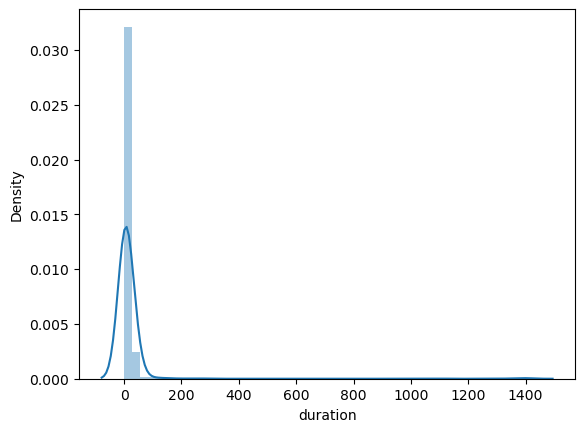

In [28]:
sns.distplot(df['duration'])

In [30]:
df['duration'].describe(percentiles=[)

count    1238.000000
mean       18.305493
std       108.364382
min         0.000000
25%         0.100000
50%         1.666667
75%        14.216667
max      1416.100000
Name: duration, dtype: float64